# Lab 6 - Wine Prediction

The following cells import our libraries and a data set from https://www.kaggle.com/datasets/rajyellow46/wine-quality that contains data for about 6.5k wines including their type (red or white) and their quality (on a 1 to 10 scale). In this lab you will be creating machine learning models to predict the type and the quality of a wine given its other attributes.

In [2]:
# library import statements
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics


In [3]:
#import data and view shape and first 5 lines
wine_data = pd.read_csv("/home/sam/notes/compSci/2611/labs/lab6/winequality.csv")
#this data was taken from https://www.kaggle.com/datasets/rajyellow46/wine-quality
print(wine_data.shape)
wine_data.head()

(6497, 13)


,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


# Data Exploration

In the following cell display the "info" about each column in the dataframe (name, non-null count, and data type). Based on this, how many columns in the data set have null values? Place your answer below.

**Answer here:** 

There are 6 columns with null values: 
'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'pH', and 'sulphates'.

In [4]:
wine_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


Null values make building machine learning models difficult. There are some clever solutions to this problem, but the easiest approach is to remove the rows that have null values. In the cell below, drop the null values and then print out the shape of the data frame. How many rows had null values?

**Answer here:** 

34 rows had null values (6497 - 6463)

In [5]:
wine_data = wine_data.dropna()
print(wine_data.shape)

(6463, 13)


As discussed in class, the "easiest" data sets to build models for are data sets with *balanced classes* meaning that the number of items you are trying to predict in each group are roughly the same. The first model that you are going to create will be to predict "red" vs "white" wine. In the cell below, count and display the number of lines that belong to each category.

In [6]:
whiteCount = count = (wine_data['type'] == 'white').sum()
redCount = count = (wine_data['type'] == 'red').sum()
print(f"White wine count: {whiteCount}")
print(f"Red wine count: {redCount}")

White wine count: 4870
Red wine count: 1593


We can see that we are dealing with reasonably imbalanced classes, so we want to be sure to try to account for that when we build our model (otherwise it might just get ~75% accuracy predicting white each time).

We now want to decipher how "good" each of our features (columns) are likely to be when making predictions. Again, there are fancier ways to do this but for now we will just compare the distributions of each variable relative to all other variables colored by the variable we want to predict. Based on the plots below, which column(s) do you think will likely be the most influential on the model you are going to create?

**Answer here:**
Fixed acidity seems to be a strong predictor, as well as chlorides.

**Note:** Because the size of this data set is much larger than the one we created in class, the following cell will take ~1 minute to run and the image *may* not render well in your browser. If this is the case, the plot will be saved to the working directory and you can view it locally on your laptop.

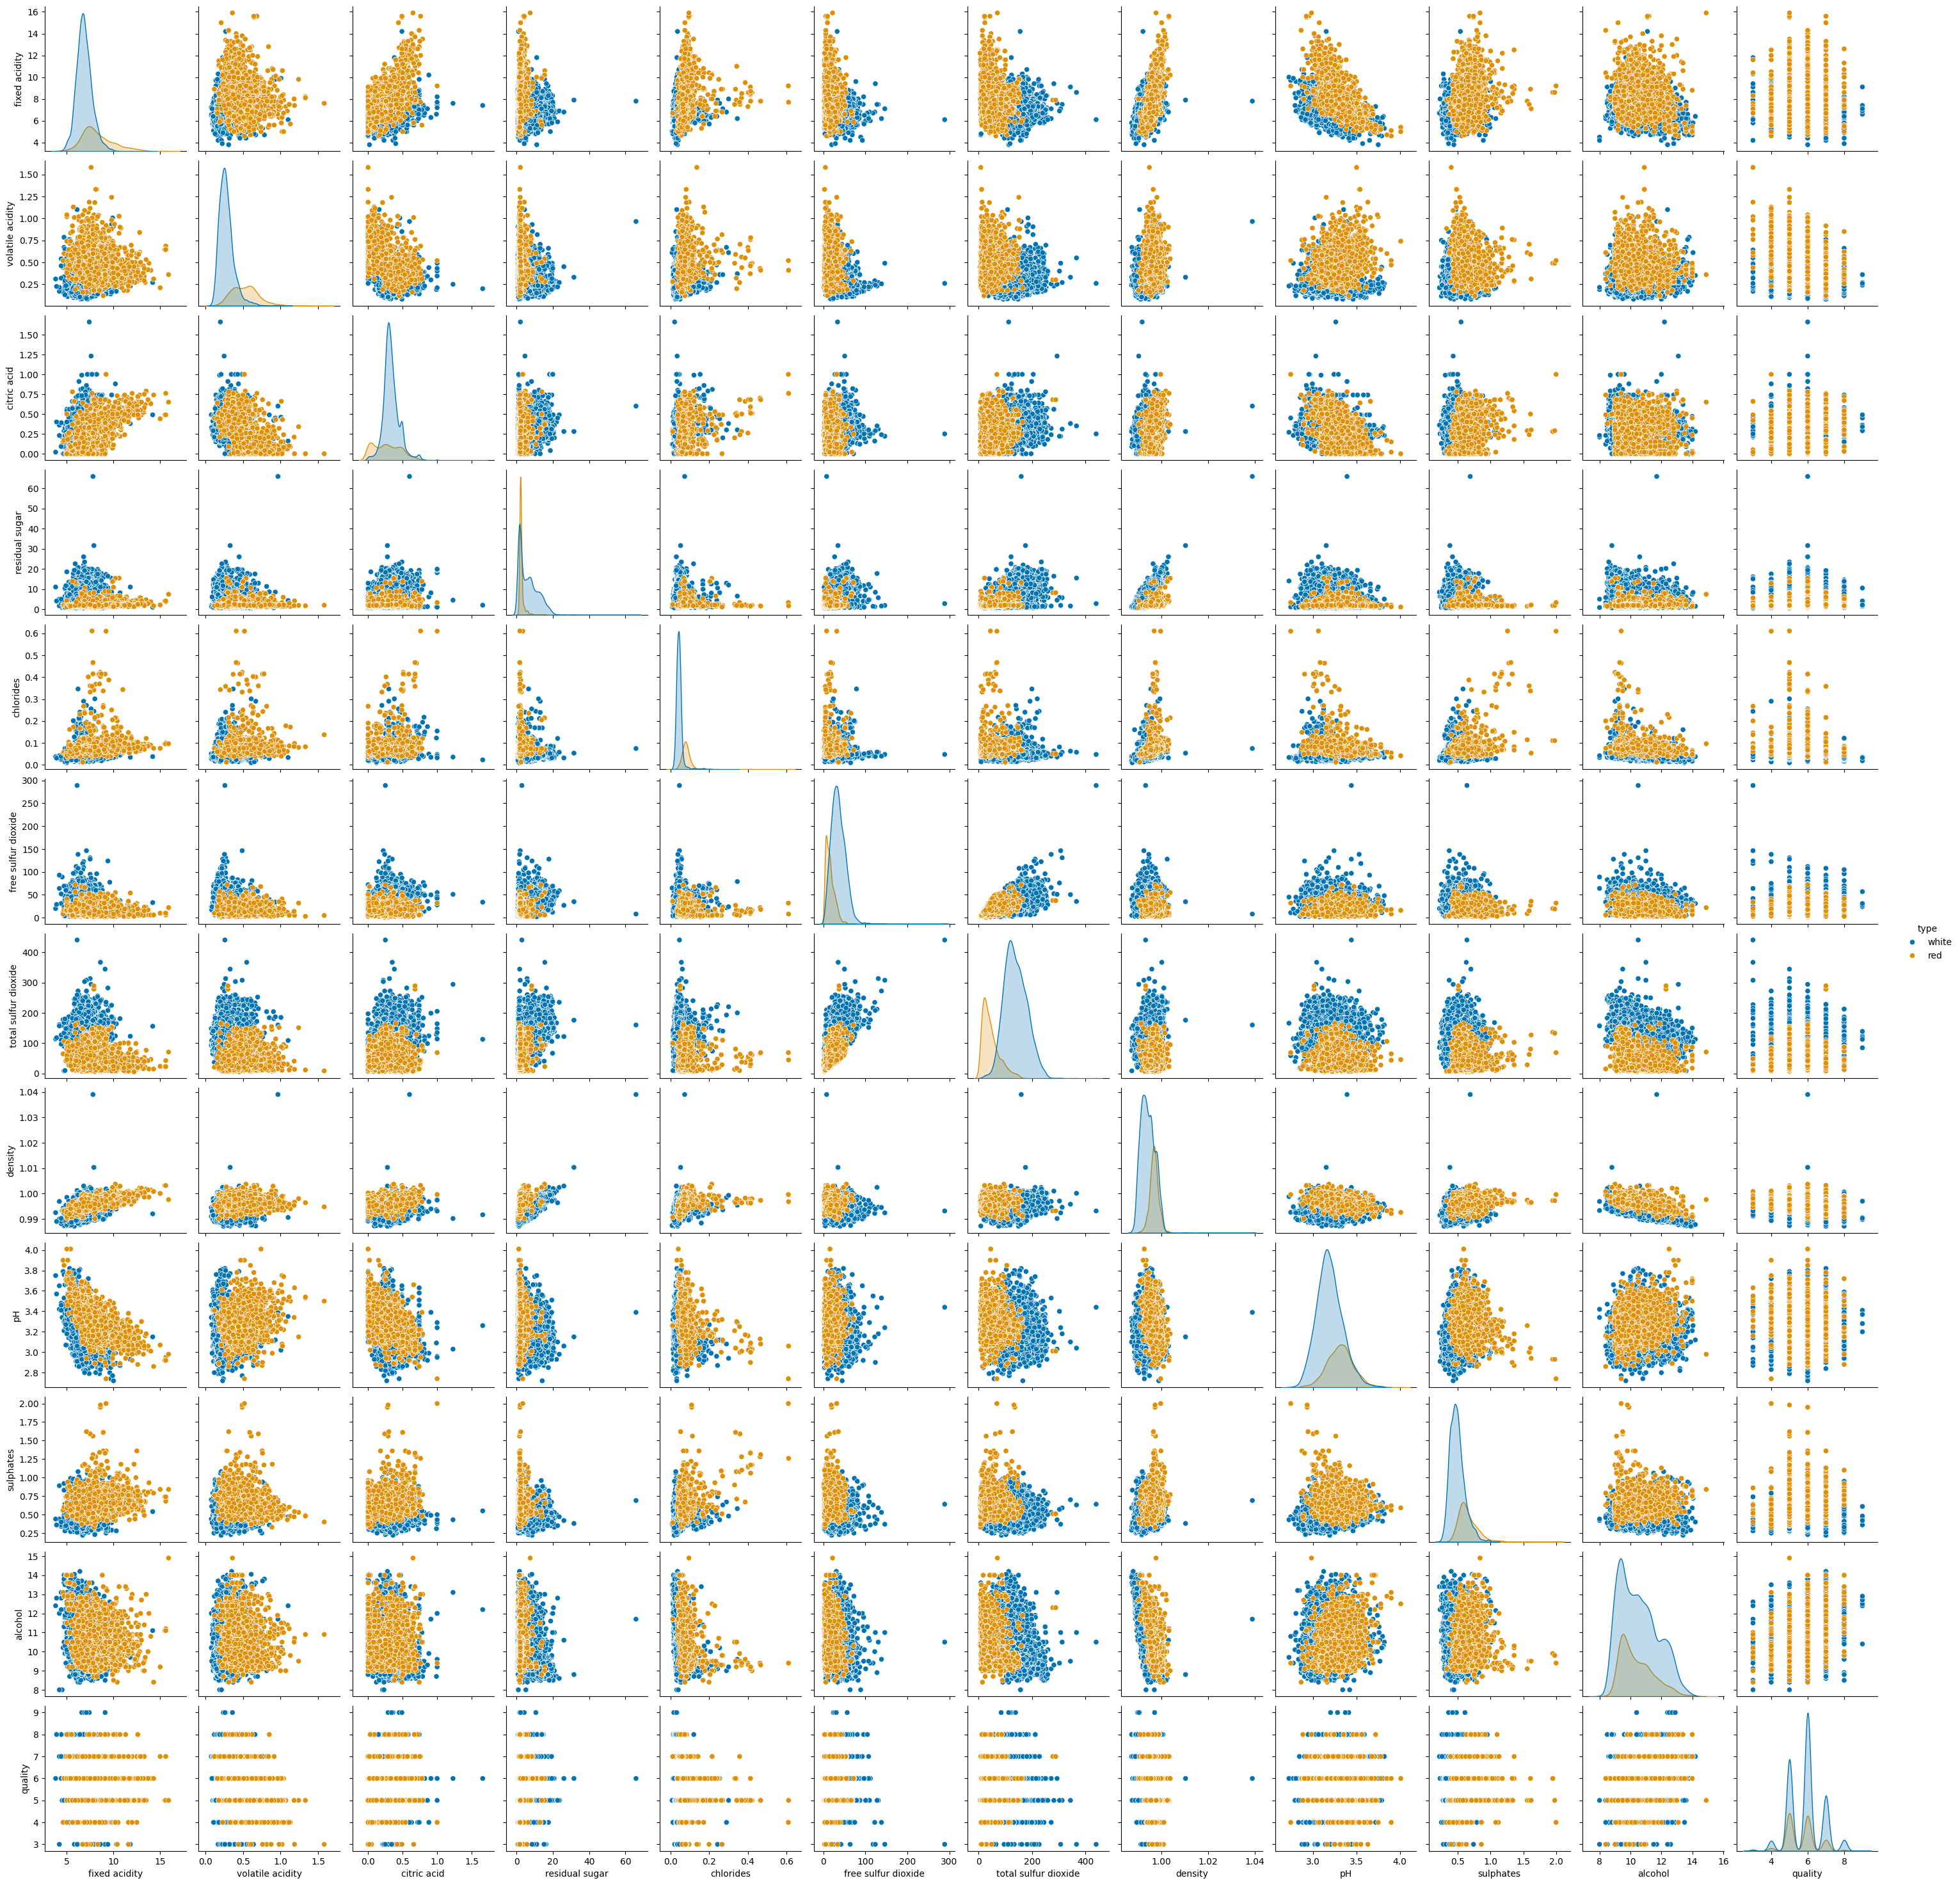

<Figure size 3088x3000 with 0 Axes>

In [7]:
plot = sns.pairplot(wine_data, hue="type", palette = 'colorblind', diag_kind="kde")
plot.savefig("pairplot.png")

plt.clf() # Clean pairplot figure from sns 
Image(filename='pairplot.png') # Show pairplot as image

# Model creation 1

Now that we have a good understanding of our data, it is time to build the model to predict wine type. The first thing that you need to do is split your model into a training and a testing set. When splitting the data create a 80-20 train-test split. Do not forget to make sure your prediction class ("type") is balanced between the training and testing sets. 

In [8]:
train, test = train_test_split(wine_data, test_size = .2, stratify = wine_data['type'], random_state = 0)

In the cell below, use a Decision Tree classifier and your above split into training and testing data to create a model to predict wine type. **Do not** limit the depth of the tree, and print out the *accuracy* of the model you created. 

In [9]:
# Train a Decision Tree classifier to predict wine type
dt_model = DecisionTreeClassifier()
dt_model.fit(train.drop('type', axis=1), train['type'])

# Predict on test set
predictions = dt_model.predict(test.drop('type', axis=1))

# Print accuracy
accuracy = metrics.accuracy_score(test['type'], predictions)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9830


In the cell below, display the features used in the model and also how important each feature was in the decision tree you created. Do the feature importances align with how predictive you thought each feature would be based on the pairplots above?

**Answer here:**

The two most important qualities seem to be chlorides and total sulfur dioxide, with fixed acidity as a close third. This substantiates the observances I made from the pair plot.

In [10]:
print(dt_model.feature_importances_)
print(dt_model.feature_names_in_)

[0.00804493 0.04766119 0.001615   0.00297257 0.21476655 0.00405344
 0.67628121 0.01235535 0.01509854 0.0112344  0.00504777 0.00086906]
['fixed acidity' 'volatile acidity' 'citric acid' 'residual sugar'
 'chlorides' 'free sulfur dioxide' 'total sulfur dioxide' 'density' 'pH'
 'sulphates' 'alcohol' 'quality']


Visualize the tree in the next cell.

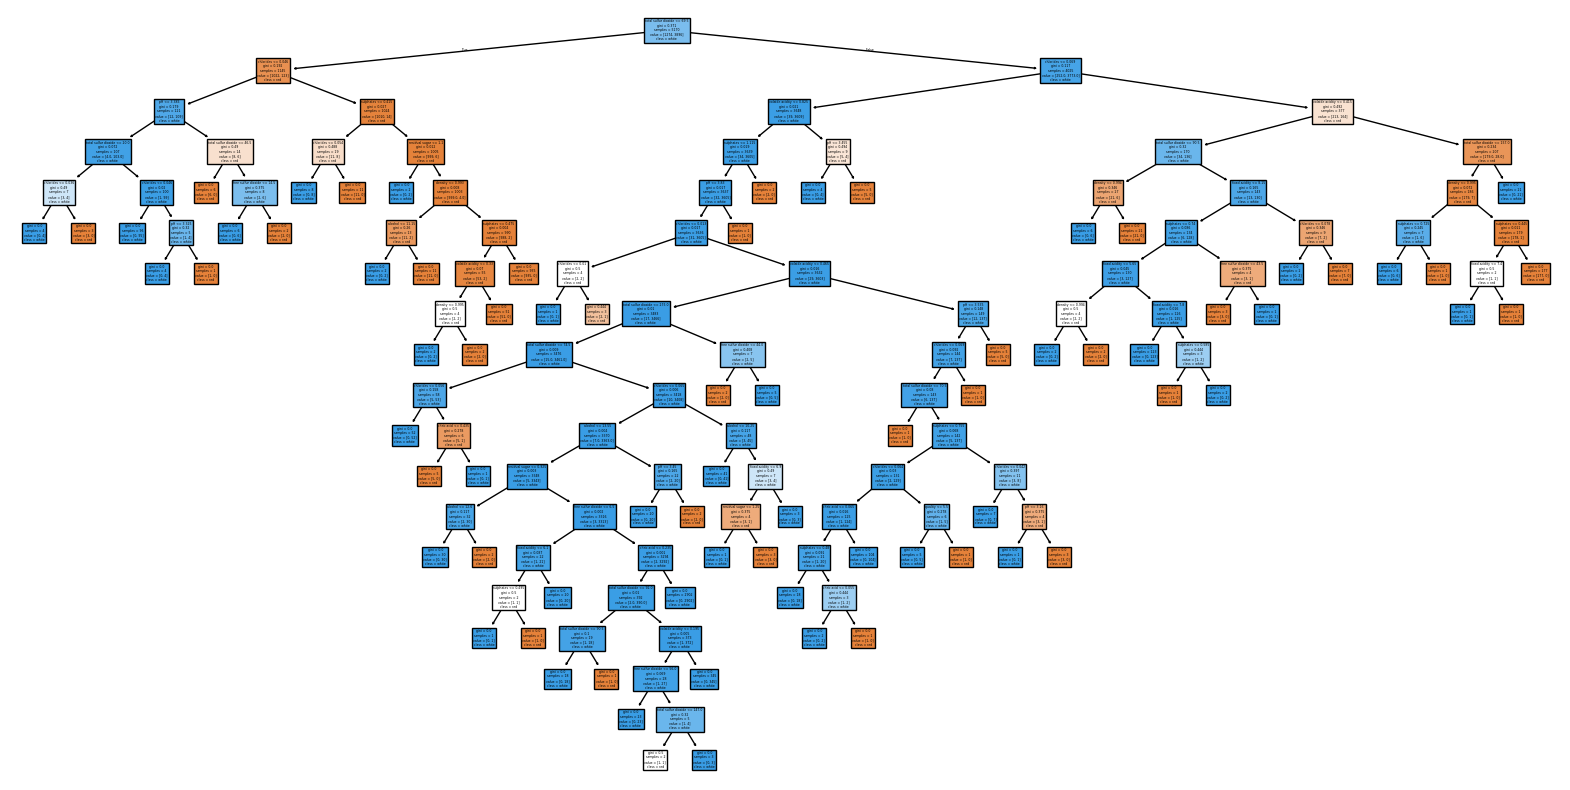

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=dt_model.feature_names_in_, class_names=dt_model.classes_, filled=True)
plt.show()

Notably, this tree is much larger than the tree we created in assignment 6. Are there any concerns about making a tree this large/complex (think - what happens if the model's decision boundaries get too complex?)?

**Answer here:**
It's possible that by creating such a complex model, we cause overfitting.

Would the model lose any accuracy if we forced it to be simpler? In the following cell, recreate your decision tree model but limit the depth of the tree to 5. Print the accuracy and visualize the tree.

Accuracy: 0.9853


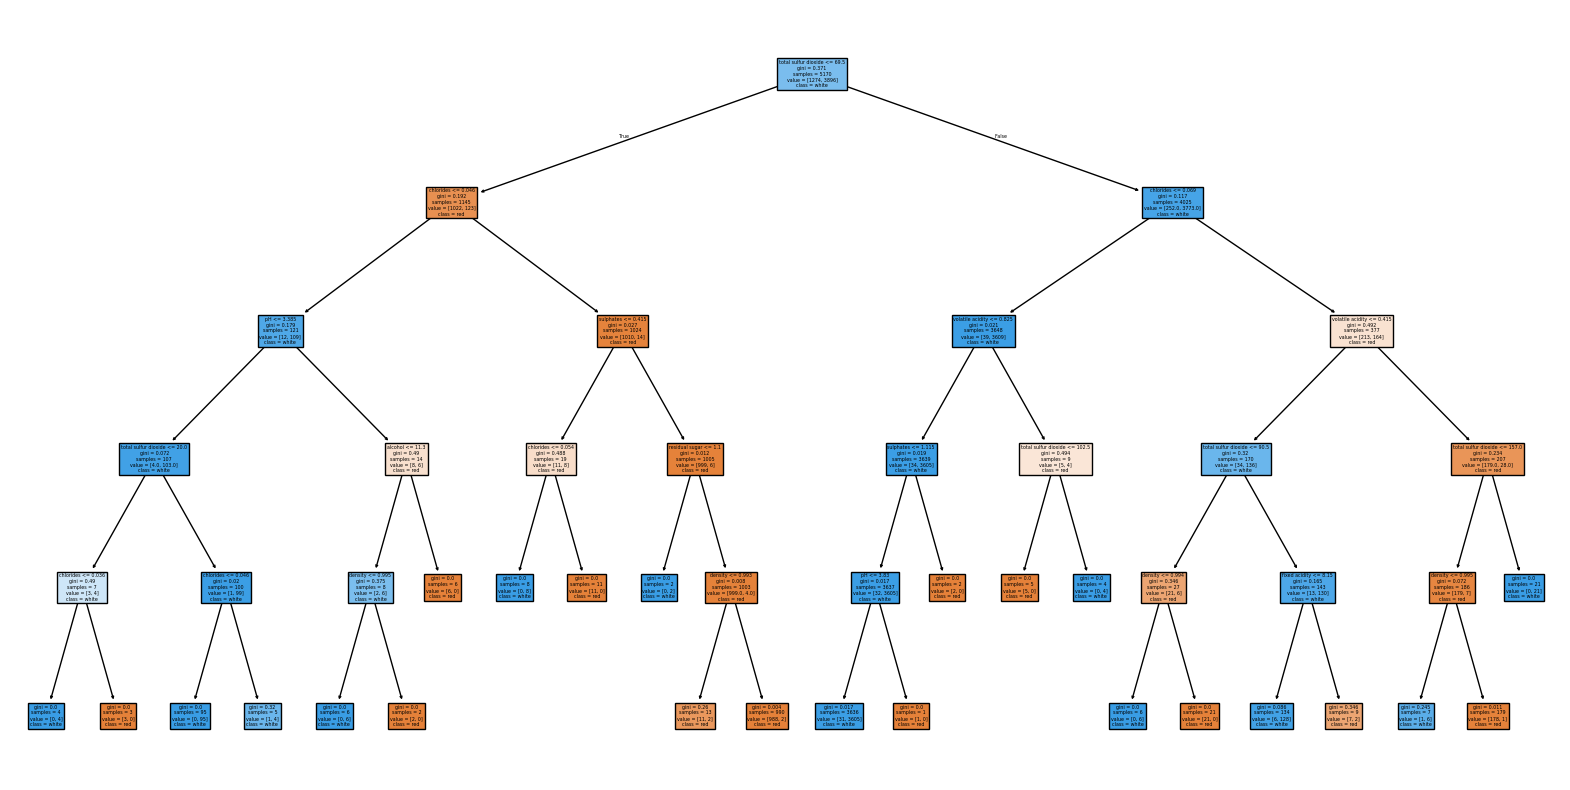

In [12]:
# Train a Decision Tree classifier to predict wine type
dt_model_small = DecisionTreeClassifier(max_depth=5)
dt_model_small.fit(train.drop('type', axis=1), train['type'])

# Predict on test set
predictions = dt_model_small.predict(test.drop('type', axis=1))

# Print accuracy
accuracy = metrics.accuracy_score(test['type'], predictions)
print(f"Accuracy: {accuracy:.4f}")

plt.figure(figsize=(20, 10))
plot_tree(dt_model_small, feature_names=dt_model_small.feature_names_in_, class_names=dt_model_small.classes_, filled=True)
plt.show()

How does this model compare to the model with unlimited depth? Is there an advantage to using the simpler model?

**Answer here:**

We lose a trivial amount of accuracy. The advantages to a simpler model include better performance, and a lesser chance of overfitting.

In the following cells, try building a model without stratifying the training and testing set. Specifically, recreate your training set to be the first 4500 rows from the data and the testing set being the remaining rows. Then use these sets to rebuild your decision tree model. Print out the accuracy, precision, and recall from your model.

In [13]:
train_unshuffled = wine_data.iloc[:4500]
test_unshuffled = wine_data.iloc[4500:]

In [14]:
# Train a Decision Tree classifier to predict wine type
dt_model_unshuffled = DecisionTreeClassifier(max_depth=5)
dt_model_unshuffled.fit(train_unshuffled.drop('type', axis=1), train_unshuffled['type'])

# Predict on test set
predictions_unshuffled = dt_model_unshuffled.predict(test_unshuffled.drop('type', axis=1))

# Print accuracy
accuracy_unshuffled = metrics.accuracy_score(test_unshuffled['type'], predictions_unshuffled)
precision_unshuffled = metrics.precision_score(test_unshuffled['type'], predictions_unshuffled, pos_label='white')
recall_unshuffled = metrics.recall_score(test_unshuffled['type'], predictions_unshuffled, pos_label='white')
print(f"Accuracy: {accuracy_unshuffled:.4f} Precision: {precision_unshuffled:.4f} Recall: {recall_unshuffled:.4f}")

Accuracy: 0.1885 Precision: 0.1885 Recall: 1.0000


What is going on here? Why does this model perform so terribly? (For reference, your accuracy should be just under 20%).

**Answer here:**

This model performs so poorly because the first segment of data, the train set, seems to contain predominantly white wine, and the second segment of data contains predominantly red wine. This means our model is trained to predict white wine, and is being tested on a dataset of mostly red wine.

# Model 2: Predicting wine quality

Finally, build a new model model on your own predicting the "quality" column of the data set. Use a model other than a decision tree (refer to assignment 6 or do your own research for a different classification algorithm). You will likely want to remove the non-numeric "type" column from your predictions (or, if you would rather, recode this column to be numeric). Print out the accuracy of your new model.

Your should achieve an accuracy of at least 46%.

In [15]:
def type_to_num(type_str):
    if type_str == 'white':
        return 1
    else:
        return 0

In [16]:
from sklearn.linear_model import LogisticRegression

# Train a Decision Tree classifier to predict wine quality
wine_data_quality = wine_data.copy()
wine_data_quality['type'] = wine_data_quality['type'].apply(type_to_num)

train_quality, test_quality = train_test_split(wine_data_quality, test_size = .2, stratify = wine_data_quality['quality'], random_state = 0)
lr_model = LogisticRegression(solver='liblinear', multi_class='ovr')
lr_model.fit(train_quality.drop('quality', axis=1), train_quality['quality'])

# Predict on test set
predictions = lr_model.predict(test_quality.drop('quality', axis=1))

# Print accuracy
accuracy = metrics.accuracy_score(test_quality['quality'], predictions)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5437


/home/sam/notes/compSci/2611/daVenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/sam/notes/compSci/2611/daVenv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


When predicting "quality" you likely did not achieve an accuracy anywhere near 98% like you did for predicting "type". What makes "quantity" an inherently more difficult thing to predict than "type"?

**Answer here:**
Quality is much more difficult to predict than type because it has a far larger range, as compared to type which has a binary range. Quality can also be dependent on many different factors, as compared to type which -- as we saw earlier -- is dependent on only a few variables.

This was likely (for most students) your first chance at building a machine learning model on your own. Please provide a brief reflection on the activity, including any concepts that were discussed here or in a previous lecture that you have questions about, or topics that you would like to learn more about. 

**Answer here:**

I have no questions on any of these topics, I would like to go more into some deep learning work, and how larger models can be run and accelerated.

This lab was created by Dr. Gabe Wright